## Tutorial on the Adult Income dataset

This notebook is a commented version of the demonstation run on the Adult Income dataset.

The first two code cells are requirements needed to run the demonstration.

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils
from helper_functions import read_adult

# for reproducibility
random.seed(42)
np.random.seed(42)

# set to False to remove assertion check
assertion_check = True

### Step 1: loading the dataset

As a first step, we load the dataset as a data panda.

Data is stored in "df", the names of the attributes are stored in "pred_atts" as a list of strings, "target" holds the name of the column where the target variable is stored ('class'), and "df_code" the encoder.

The "read_adult" function also takes care of cleaning the data and missing values imputation. It needs to be adapted for new datasets.

Using "df.info()", we display the metadata of the dataframe.

In [3]:
df, pred_atts, target, df_code = read_adult(continuous_only=False, simplified=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   race          48842 non-null  str  
 1   sex           48842 non-null  str  
 2   workclass     48842 non-null  str  
 3   education     48842 non-null  str  
 4   age           48842 non-null  int64
 5   capitalgain   48842 non-null  int64
 6   capitalloss   48842 non-null  int64
 7   hoursperweek  48842 non-null  int64
 8   class         48842 non-null  str  
dtypes: int64(4), str(5)
memory usage: 3.4 MB


### Step 2: encoding the dataset

We create a new dataframe for the encoded data ("df_encoded_onehot") and create a new list that holds the column names of all encoded attributes ("encoded_pred_atts"). For example, since gender is encoded binary ("male", "female"), this results in two columns in the one-hot-encoding and thus two column names ("sex_Female", "sex_Male").

We also print the first 5 lines of the encoded dataframe ("df_encoded_onehot.head()". The encoded dataframe contains 21 columns.

In [4]:
df_encoded_onehot = df_code.fit_transform(df)
encoded_pred_atts = df_code.encoded_atts(pred_atts)
df_encoded_onehot.head()

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,...,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek,class
0,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,13,39,2174,0,40,0
1,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,13,50,0,0,13,0
2,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,9,38,0,0,40,0
3,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,7,53,0,0,40,0
4,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,13,28,0,0,40,0


### Step 3: Splitting the dataset

We read from the encoded dataframe the attributes ("X") and target ("y"). Then, we split them each into a training and a test set, in the ratio of 7:3.

In [5]:
X, y = df_encoded_onehot[encoded_pred_atts], df_encoded_onehot[target]
X1, XT1, y1, yt1 = train_test_split(X, y, test_size=0.3, random_state=42)

### Step 4: Traing the ML model

We train a decision tree -- out ML model in this demonstration -- on the training set ("X1" with target "y1"). While the first line specifies the parameters of the tree, the second creates the trained tree (in "clf1").

The code in the following cell is to visualize the trained tree.

In [6]:
clf1 = DecisionTreeClassifier(max_depth=3, min_impurity_decrease=0.0001)
clf1.fit(X1, y1)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0001
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :ter

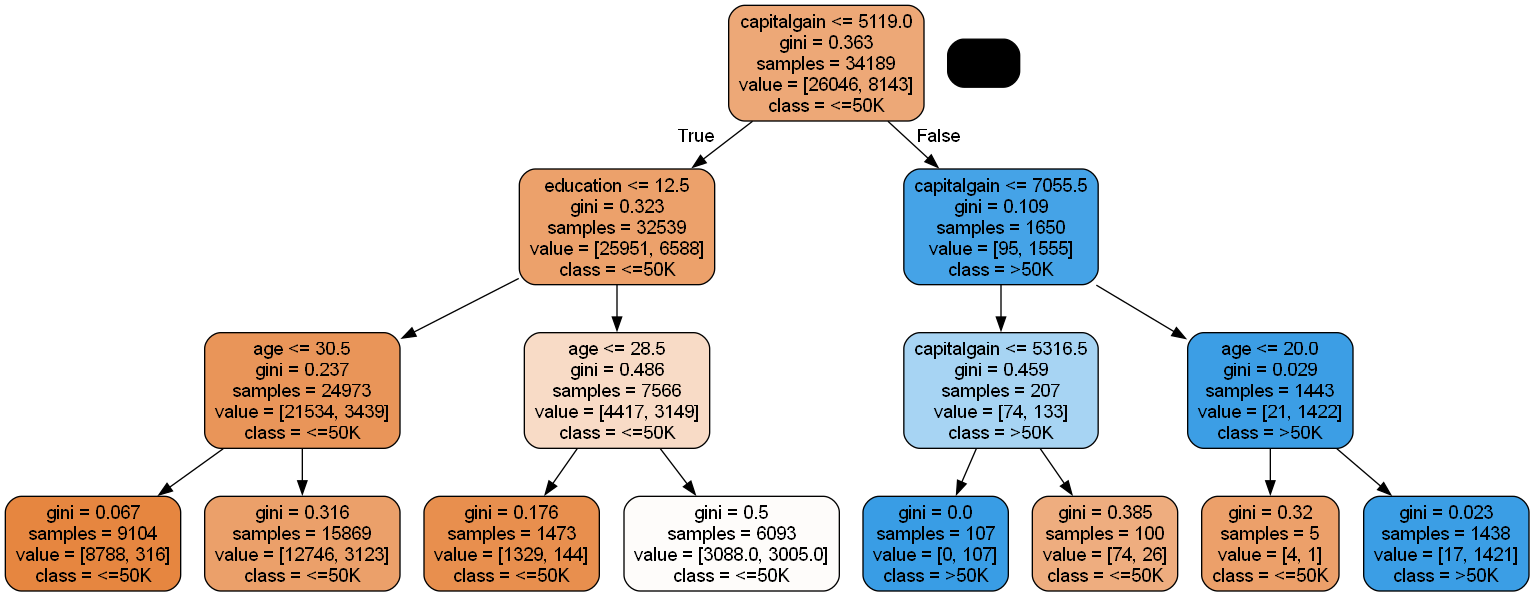

In [7]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree
dot_data = tree.export_graphviz(clf1, out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

### Step 5: Computing the accuracy

In the following code cell, we predict the labels of the test dataset, and compute the accuracy score (the fraction of correct predictions, the higher the better).

In [8]:
ypred = clf1.predict(XT1)
accuracy_score(yt1, ypred)

0.801610591687709

### Step 6: Initialize ReasonX

To compute explanations with ReasonX, we first need to initialize it. To this end, we pass the column names of the attributes, the column name of the target variable and the encoder to ReasonX. Additionally, we specific the ML model to explain ("clf1").

In [9]:
# initialise ReasonX
r = reasonx.ReasonX(pred_atts, target, df_code)
r.model(clf1)

In [10]:
# fix instance to explain
inst = 6569
x_features = XT1.iloc[inst:(inst+1)]
x_class = yt1.iloc[inst]
x_features

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,workclass_Private,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek
27026,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,10,19,0,0,40


### Step 7: Create several explanations with ReasonX

First, we compute the factual rule of a single data instance (the rule behind the prediction of the ML model for this instance). To do this, we first need to initialize this instance - here, we pass the first instance from the training set, together with its label. We name this instance "F".

Using "solveopt()", we obtain the explanation in the form of a single decision rule ("rule satisfied by F").

In [11]:
# Why was my credit application rejected?
# factual rule on an instance
r.instance('F', features=x_features, label=x_class)
r.solveopt()

---
Answer constraint: F.race=AsianPacIslander,F.sex=Male,F.workclass=Private,F.education=10.0,F.age=19.0,F.capitalgain=0.0,F.capitalloss=0.0,F.hoursperweek=40.0
Rule satisfied by F: IF F.capitalgain<=5119.0,F.education<=12.5,F.age<=30.5 THEN <=50K [0.9653, 0.2663]


In the next step, we want to obtain the contrastive explanation (the rule(s) that lead to a decision opposite to that of the instance on interest). We need to initialize an additional instance with a new name (here "CF"), and new label (here: one minus the original label - since the decision problem is binary and there is a one-hot-encoding, we obtain the other label). Additionally, we set a minimum confidence value "minconf".

We obtain the results using again "solveopt()". We obtain two such contrastive rules - dispayed in "answer constraint" and "rule satisfied by CF".

In [12]:
# What are my options to change the outcome of the ADM, and receive the credit?
# contrastive rules with min conf
r.instance('CE', label=1-x_class, minconf=0.8)
r.solveopt(project=['CE'])
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.capitalgain>5119.0,CE.capitalgain<=5316.5', 'CE.capitalgain>7055.5,CE.age>20.0']

---
Answer constraint: CE.capitalgain>5119.0,CE.capitalgain<=5316.5
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE: IF CE.capitalgain>5119.0,CE.capitalgain<=5316.5 THEN >50K [1.0000, 0.0031]
---
Answer constraint: CE.capitalgain>7055.5,CE.age>20.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE: IF CE.capitalgain>7055.5,CE.age>20.0 THEN >50K [0.9882, 0.0421]


In the next step, we add a constraint to the problem: we don't want that the feature age changes between factual and contrastive instance. To realize this, we use the "constraint()" functionality. Running "solveopt()" again, without any arguments in the brackets, we now obtain the contrastive decision rule that satisfies the stated constraint.

Given the constraint, only one of the previous two rules is admissible - thus we obtain only one rule.

In [13]:
# Add background knowledge
r.constraint("CE.age = F.age")
r.solveopt(project=['CE'])
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.age=19.0,CE.capitalgain>5119.0,CE.capitalgain<=5316.5']

---
Answer constraint: CE.age=19.0,CE.capitalgain>5119.0,CE.capitalgain<=5316.5
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [1.0000]
Rule satisfied by CE: IF CE.capitalgain>5119.0,CE.capitalgain<=5316.5 THEN >50K [1.0000, 0.0031]


Now, we want to obtain the closest contrastive data instance. To this end, we don't need to declare a new instance.

However, in the "solveopt()", need to specific that we want to optimize for a distance between the original instance and the contrastive instance: here, we decide for the "l1norm". Additionally, we specific that the results should be projected on "CF" for better readability, and set the paramter "eps" to 0.01 (default).

The result is now one contrastive data instances, for which the exact values are stated (see the assigned values in "answer constraints"). We also obtain the distance between factual and contrastive instance ("min value"). The output additionally displays the contrastive rule, i.e., rule satisfied by the contrastive instance (or equivalently, the branche in the DT where the instance is located). It is the same as the rule obtained with the previous query.

In [14]:
# Minimal contrastive explanation
r.solveopt(minimize='l1norm(F, CE)', project=['CE'], eps=0.01)
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.race=AsianPacIslander,CE.sex=Male,CE.workclass=Private,CE.education=10.0,CE.age=19.0,CE.capitalgain=5119.010000000013,CE.capitalloss=0.0,CE.hoursperweek=40.0']

---
Answer constraint: CE.race=AsianPacIslander,CE.sex=Male,CE.workclass=Private,CE.education=10.0,CE.age=19.0,CE.capitalgain=5119.010000000013,CE.capitalloss=0.0,CE.hoursperweek=40.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [1.0000]
Min value:0.0512
Rule satisfied by CE: IF CE.capitalgain>5119.0,CE.capitalgain<=5316.5 THEN >50K [1.0000, 0.0031]


In the next step, we want work with an underspecified factual instance, i.e. an instance for which not all features are fully specificied. Specifically, the feature age should be equal or smaller than 19.

To this end, we first "delete" the exact value of the feature age of the factual instance. Since this is encoded in the system as a constraint, we can simply retract the corresponding constraint. Then, we need to assert a new constraint: "F.age<=19.0".

We solve for the clostest constrastive instance as before. To make it a bit easier to read the output, we additionally project on the feature age of the facutal instance.

Recalling that we still have an equality constraint on the feature age of the factual and contrastive instance, we obtain one solution that is the same as before but with the feature age set also to 19 or smaller (see the last two constraints in "answer constraint"). 

In [15]:
# Under-specified instance
r.retract("F.age=19.0")
r.constraint("F.age<=19.0")
r.solveopt(minimize='l1norm(F, CE)', project=["CE"], eps=0.01)
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.race=AsianPacIslander,CE.sex=Male,CE.workclass=Private,CE.education=10.0,CE.capitalgain=5119.010000000013,CE.capitalloss=0.0,CE.hoursperweek=40.0,CE.age<=19.0']

1 constraint(s) retracted
---
Answer constraint: CE.race=AsianPacIslander,CE.sex=Male,CE.workclass=Private,CE.education=10.0,CE.capitalgain=5119.010000000013,CE.capitalloss=0.0,CE.hoursperweek=40.0,CE.age<=19.0
Contrastive rule satisfied by CE: IF Answer constraint THEN >50K [1.0000]
Min value:0.0512
Rule satisfied by CE: IF CE.capitalgain>5119.0,CE.capitalgain<=5316.5 THEN >50K [1.0000, 0.0031]


In [16]:
r.solveopt(minimize='l1norm(F, CE)', project=["CE", "F.age"], eps=0.01)
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['CE.race=AsianPacIslander,CE.sex=Male,CE.workclass=Private,CE.education=10.0,CE.capitalgain=5119.010000000013,CE.capitalloss=0.0,CE.hoursperweek=40.0,F.age<=19.0,CE.age=F.age']

---
Answer constraint: CE.race=AsianPacIslander,CE.sex=Male,CE.workclass=Private,CE.education=10.0,CE.capitalgain=5119.010000000013,CE.capitalloss=0.0,CE.hoursperweek=40.0,F.age<=19.0,CE.age=F.age
Min value:0.0512
Rule satisfied by CE: IF CE.capitalgain>5119.0,CE.capitalgain<=5316.5 THEN >50K [1.0000, 0.0031]


In [17]:
# setting minimum coverage on factual and contrastive instance
r.reset(keep_model=True)
r.instance('F', features=x_features, label=x_class, mincov=0.2)
r.instance('CE', label=1-x_class, minconf=0.8, mincov=0.02)
r.solveopt()
CE_answers = r.answers()
if assertion_check:
    assert CE_answers == ['F.race=AsianPacIslander,F.sex=Male,F.workclass=Private,F.education=10.0,F.age=19.0,F.capitalgain=0.0,F.capitalloss=0.0,F.hoursperweek=40.0,CE.capitalgain>7055.5,CE.age>20.0']

---
Answer constraint: F.race=AsianPacIslander,F.sex=Male,F.workclass=Private,F.education=10.0,F.age=19.0,F.capitalgain=0.0,F.capitalloss=0.0,F.hoursperweek=40.0,CE.capitalgain>7055.5,CE.age>20.0
Rule satisfied by F: IF F.capitalgain<=5119.0,F.education<=12.5,F.age<=30.5 THEN <=50K [0.9653, 0.2663]
Rule satisfied by CE: IF CE.capitalgain>7055.5,CE.age>20.0 THEN >50K [0.9882, 0.0421]
